plot cluster correctness versus number of links between modules

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
import networkx as nx
from sklearn import metrics
import pickle
import os

import metaCommunityMx
import community_sim
import metrics_and_plotting
import run_cooccurrence
reload(metaCommunityMx)
reload(community_sim)
reload(metrics_and_plotting)
reload(run_cooccurrence)

os.makedirs('figure_data', exist_ok=True)

In [2]:
# for random matrix
nSpec = 100
pPositive = 0.5
# pInteract = 0.05 # this is only used for random matrix
pInteract = 0.1735 # this makes the same number of interactions as modular mx with nSpec = 100, nModules = 5, pWithinMod = 0.9, pBetweenMod = 0.001

# for modular matrix or hub mx
nModules = 5
pWithinMod = 0.9

# parms for GLV sim
alpha = 0.001
# interactStren = alpha * interactFactor
samplesize = int(0.5 * nSpec) # number of species to sample
numtrials = 500
b = np.ones(nSpec) - np.random.uniform(low = 0, high = .1, size = (nSpec))

Run simulation

Take the modular matrix with no interactions between modules, run the simulation and calculate the module correctness, then add interactions between modules and see how long it takes to lose the signal

1722
0


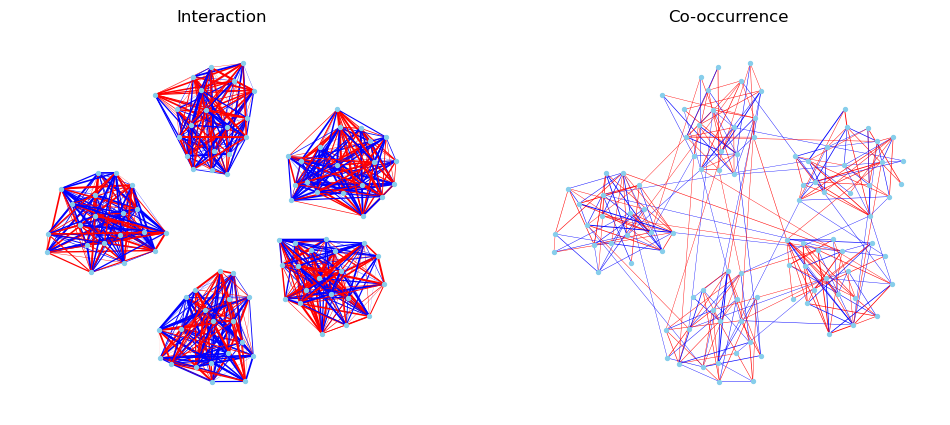

1526
196


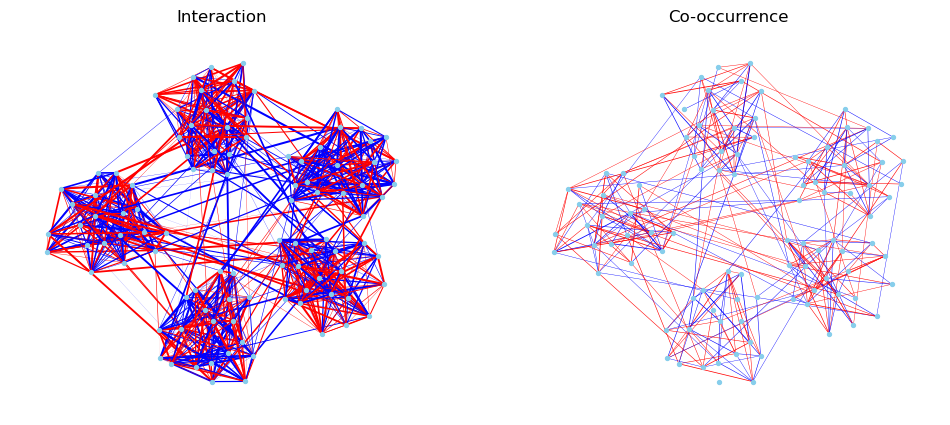

1332
390


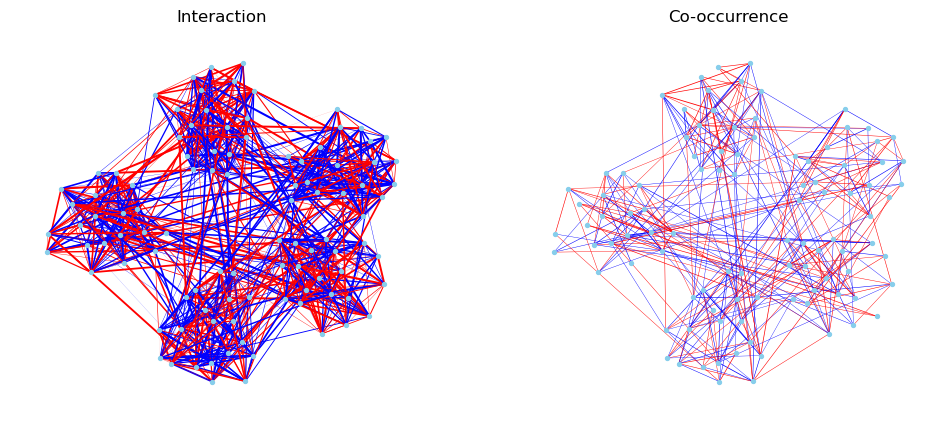

1148
574


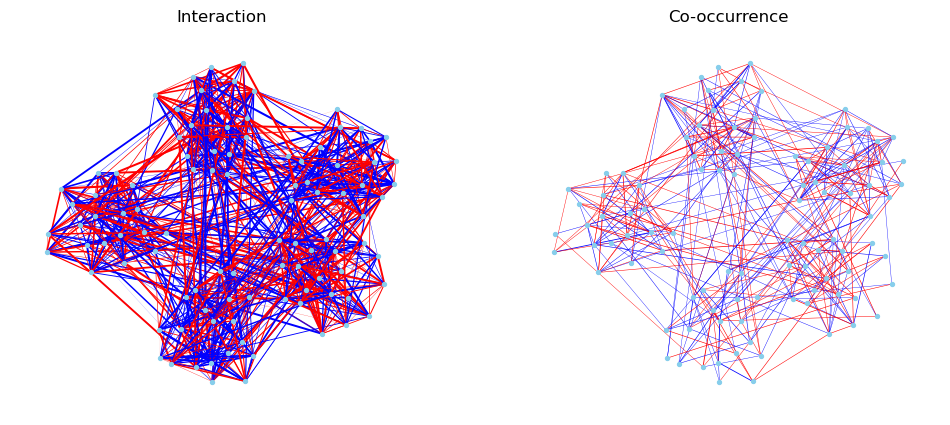

In [ ]:
modSize = nSpec // nModules
myModules = [range(i * modSize, (i+1) * modSize) for i in range(nModules)]

step = 50
maxEBetween = 1500

####### to get null expectation for random network
interactFactor = 1/10
randMx = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactFactor * alpha, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)

network_rand, G_rand_coocc = run_cooccurrence.get_coocc_network(interactionMx = randMx, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, pval_alpha = 0.01)
rand_clust_coocc_gr = nx.community.greedy_modularity_communities(G_rand_coocc)

G_rand_inter = nx.from_numpy_array(randMx != 0)
rand_clust_inter_gr = nx.community.greedy_modularity_communities(G_rand_inter)

rand_shared_pairs_10, rand_both_non_pairs_10, rand_c1_not_c2_10, rand_c2_not_c1_10, rand_prop_correct_10 = \
                metrics_and_plotting.test_cluster_similarity(rand_clust_coocc_gr, rand_clust_inter_gr)

interactFactor = 1/5
randMx = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactFactor * alpha, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)

network_rand, G_rand_coocc = run_cooccurrence.get_coocc_network(interactionMx = randMx, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, pval_alpha = 0.01)
rand_clust_coocc_gr = nx.community.greedy_modularity_communities(G_rand_coocc)

G_rand_inter = nx.from_numpy_array(randMx != 0)
rand_clust_inter_gr = nx.community.greedy_modularity_communities(G_rand_inter)

rand_shared_pairs_3, rand_both_non_pairs_5, rand_c1_not_c2_5, rand_c2_not_c1_5, rand_prop_correct_5 = \
                metrics_and_plotting.test_cluster_similarity(rand_clust_coocc_gr, rand_clust_inter_gr)

interactFactor = 1/3
randMx = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactFactor * alpha, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)

network_rand, G_rand_coocc = run_cooccurrence.get_coocc_network(interactionMx = randMx, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, pval_alpha = 0.01)
rand_clust_coocc_gr = nx.community.greedy_modularity_communities(G_rand_coocc)

G_rand_inter = nx.from_numpy_array(randMx != 0)
rand_clust_inter_gr = nx.community.greedy_modularity_communities(G_rand_inter)

rand_shared_pairs_3, rand_both_non_pairs_3, rand_c1_not_c2_3, rand_c2_not_c1_3, rand_prop_correct_3 = \
                metrics_and_plotting.test_cluster_similarity(rand_clust_coocc_gr, rand_clust_inter_gr)

####### get positions for the graphs
modMx = metaCommunityMx.generateModularMatrix(maxInteractionStrength = (1/10) * alpha, pPositive = pPositive, nSpecies = nSpec, pWithinMod = pWithinMod, pBetweenMod = 0, nModules = nModules)
modMxPositional = metrics_and_plotting.rewire_modular(matrix = modMx, modules = myModules, nEdges = 200, interactStren = (1/10) * alpha)
G_inter = nx.from_numpy_array(modMxPositional != 0)
pos = nx.spring_layout(G_inter, seed=42)
#######

n_reps = 15
interactFactorL = [1/3, 1/5, 1/10]
correct_clust_res = np.zeros(shape = (maxEBetween//step, 6, len(interactFactorL), n_reps))
edgeCounts = np.zeros(shape = (maxEBetween//step, 4, len(interactFactorL), n_reps))
correct_clust_res_null = np.zeros(shape = (maxEBetween//step, len(interactFactorL), n_reps))
for iiii in range(n_reps):
    for iii in range(len(interactFactorL)):
        interactFactor = interactFactorL[iii]
        interactStren = alpha * interactFactor
        modMx = metaCommunityMx.generateModularMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, nSpecies = nSpec, pWithinMod = pWithinMod, pBetweenMod = 0, nModules = nModules)

        i = 0
        for nBetween in range(0, maxEBetween, step): # slowly increase the number of links between modules
            # run simulation to get cooccurrence and make clusters
            if nBetween in [0, 200, 400, 600] and interactFactor == 1/5 and iiii == 0:
                plotNet = True
                edgeCountWithin, possibleWithin, edgeCountBetween, possibleBetween = metrics_and_plotting.prop_within_btwn_mod(nSpec, nModules, modMx)
                print(edgeCountWithin)
                print(edgeCountBetween)
            else: 
                plotNet = False
            network_mod, G_mod_coocc, pearson_mod = run_cooccurrence.get_coocc_network(interactionMx = modMx, cutoff = None, alpha = alpha, spsamplesize = samplesize, \
                                                                          numtrials = numtrials, b = b, plotNetworks = plotNet, pval_alpha = 0.01, pos = pos, return_pearson = True)
            if plotNet:
                with open(f'figure_data/mcc_network_nBetween{nBetween}.pkl', 'wb') as f:
                    pickle.dump({
                        'interactionMx': modMx,
                        'network_coocc': network_mod,
                        'pearson_corr': pearson_mod,
                        'pos': pos,
                        'nBetween': nBetween,
                    }, f)
            mod_clust_coocc_gr = nx.community.greedy_modularity_communities(G_mod_coocc)

            # make interaction clusters
            G_mod_inter = nx.from_numpy_array(modMx != 0)
            mod_clust_inter_gr = nx.community.greedy_modularity_communities(G_mod_inter)

            # compare interaction clusters and cooccurrence clusters
            mod_shared_pairs, mod_both_non_pairs, mod_c1_not_c2, mod_c2_not_c1, mod_prop_correct = \
                        metrics_and_plotting.test_cluster_similarity(mod_clust_coocc_gr, mod_clust_inter_gr)
            correct_clust_res[i,:,iii,iiii] = np.array([nBetween, mod_shared_pairs, mod_both_non_pairs, mod_c1_not_c2, mod_c2_not_c1, mod_prop_correct])

            # null cooccurrence network: same number of false pos/neg as the real cooc network, but in random positions
            null_cooc_net, _ = metrics_and_plotting.make_random_mistakes(modMx, network_mod)
            G_null_coocc = nx.from_numpy_array(null_cooc_net)
            null_clust_coocc_gr = nx.community.greedy_modularity_communities(G_null_coocc)
            _, _, _, _, mod_prop_correct_null = \
                        metrics_and_plotting.test_cluster_similarity(null_clust_coocc_gr, mod_clust_inter_gr)
            correct_clust_res_null[i,iii,iiii] = mod_prop_correct_null

            edgeCountWithin, possibleWithin, edgeCountBetween, possibleBetween = metrics_and_plotting.prop_within_btwn_mod(nSpec, nModules, modMx)
            edgeCounts[i, :, iii, iiii] = np.array([edgeCountWithin, possibleWithin, edgeCountBetween, possibleBetween])

            modMx = metrics_and_plotting.rewire_modular(matrix = modMx, modules = myModules, nEdges = step, interactStren = interactStren)
            i += 1

# correct_clust_res

1702
0
0.0


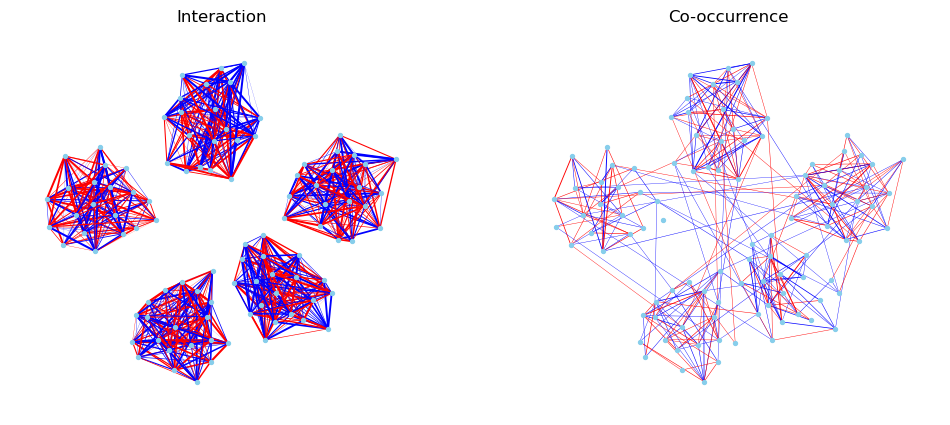

1504
198
0.11633372502937721


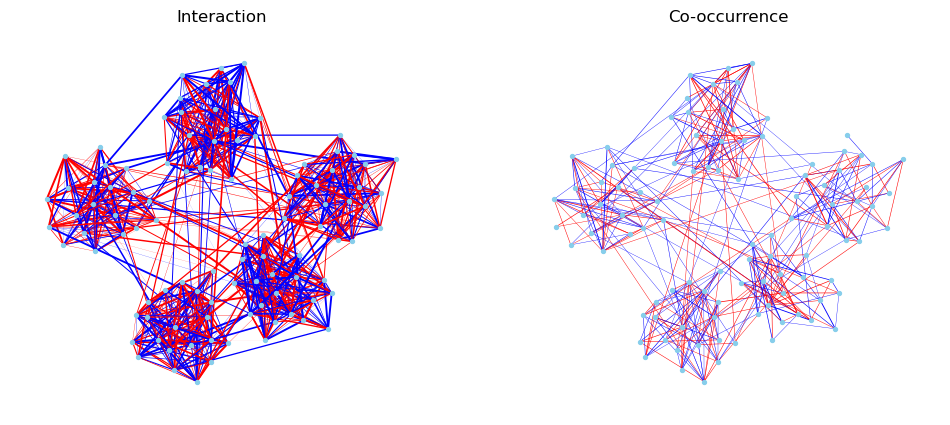

1317
385
0.22620446533490013


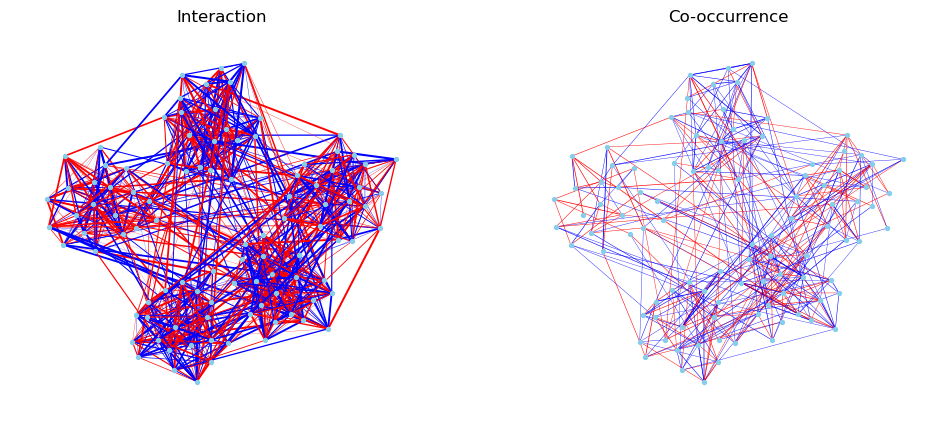

1132
570
0.33490011750881316


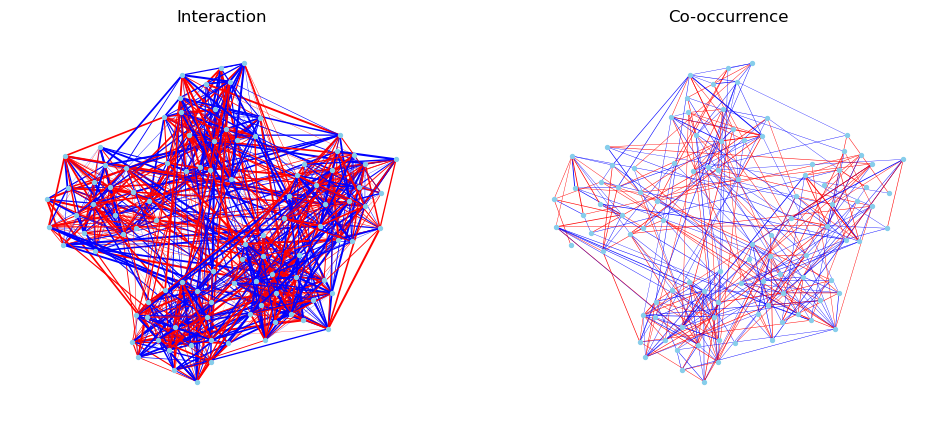

947
755
0.4435957696827262


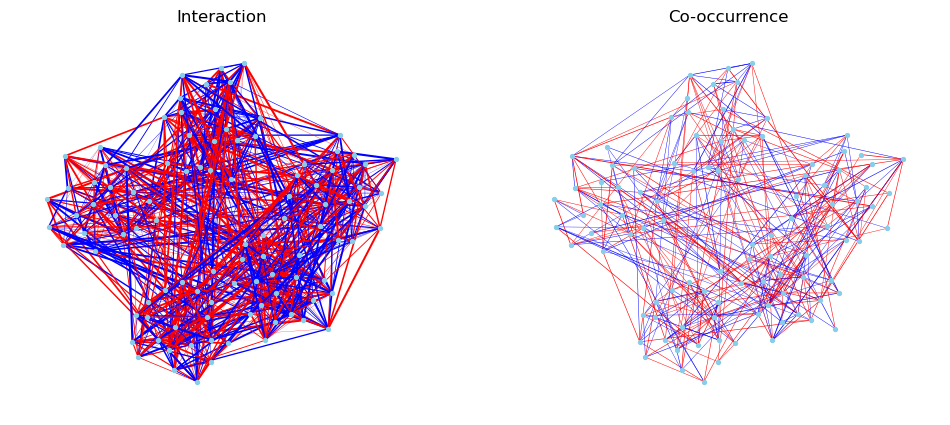

774
928
0.54524089306698


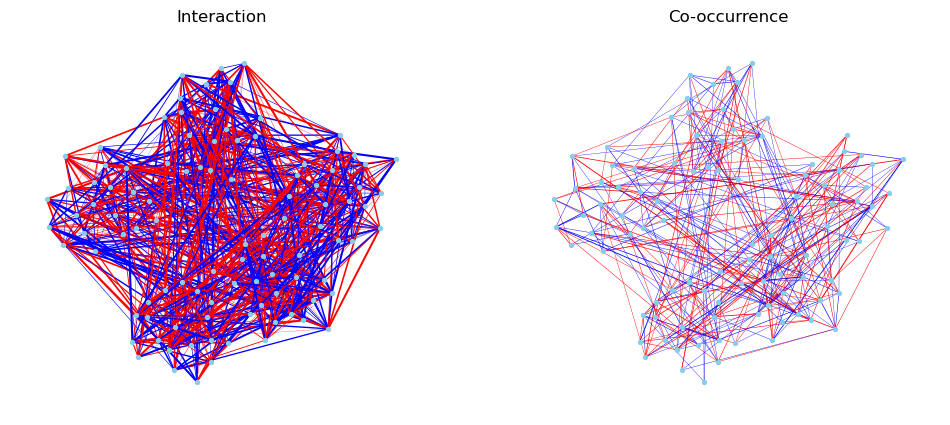

613
1089
0.6398354876615746


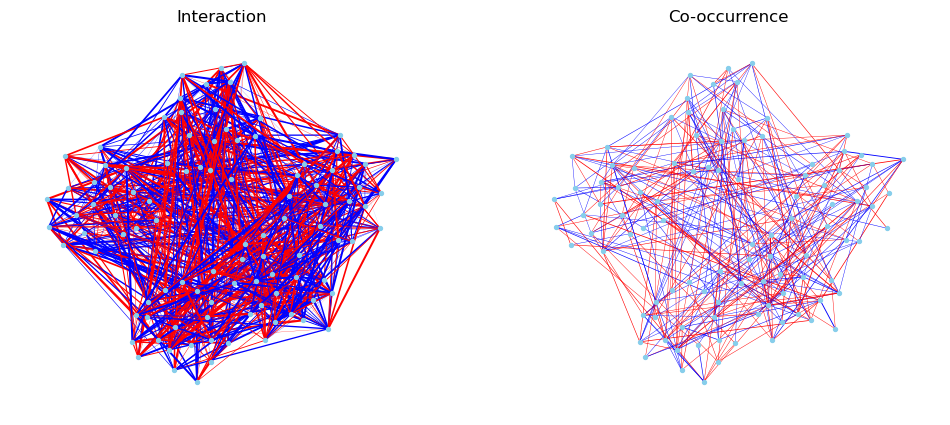

In [ ]:
interactFactor = 1/5
interactStren = alpha * interactFactor
modMx = metaCommunityMx.generateModularMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, nSpecies = nSpec, pWithinMod = pWithinMod, pBetweenMod = 0, nModules = nModules)

step = 200
maxEBetween = 1400
i = 0
for nBetween in range(0, maxEBetween, step): # slowly increase the number of links between modules
    # run simulation to get cooccurrence and make clusters
    plotNet = True
    edgeCountWithin, possibleWithin, edgeCountBetween, possibleBetween = metrics_and_plotting.prop_within_btwn_mod(nSpec, nModules, modMx)
    print(edgeCountWithin)
    print(edgeCountBetween)
    print(edgeCountBetween / (edgeCountWithin+edgeCountBetween))
    network_mod, G_mod_coocc, pearson_mod = run_cooccurrence.get_coocc_network(interactionMx = modMx, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, plotNetworks = plotNet, pval_alpha = 0.01, pos = pos, return_pearson = True)
    with open(f'figure_data/mcc_network_vis_nBetween{nBetween}.pkl', 'wb') as f:
        pickle.dump({
            'interactionMx': modMx,
            'network_coocc': network_mod,
            'pearson_corr': pearson_mod,
            'pos': pos,
            'nBetween': nBetween,
        }, f)
    modMx = metrics_and_plotting.rewire_modular(matrix = modMx, modules = myModules, nEdges = step, interactStren = interactStren)

In [ ]:
# print(total_edges[1:2,1:3,1:4])
# edgeCounts.shape
# total_edges.shape
# correct_clust_res.shape

In [ ]:
# total_edges = edgeCounts[:,0,:,:] + edgeCounts[:,2,:,:]
# edge_proportion = edgeCounts[:,2,:,:] / total_edges

# edge_proportion.shape

In [ ]:
with open('figure_data/mcc_cluster_correctness.pkl', 'wb') as f:
    pickle.dump({
        'edgeCounts': edgeCounts,
        'correct_clust_res': correct_clust_res,
        'correct_clust_res_null': correct_clust_res_null,
        'interactFactorL': interactFactorL,
        'n_reps': n_reps,
        'maxEBetween': maxEBetween,
        'rand_prop_correct_3': rand_prop_correct_3,
        'rand_prop_correct_5': rand_prop_correct_5,
        'rand_prop_correct_10': rand_prop_correct_10,
    }, f)

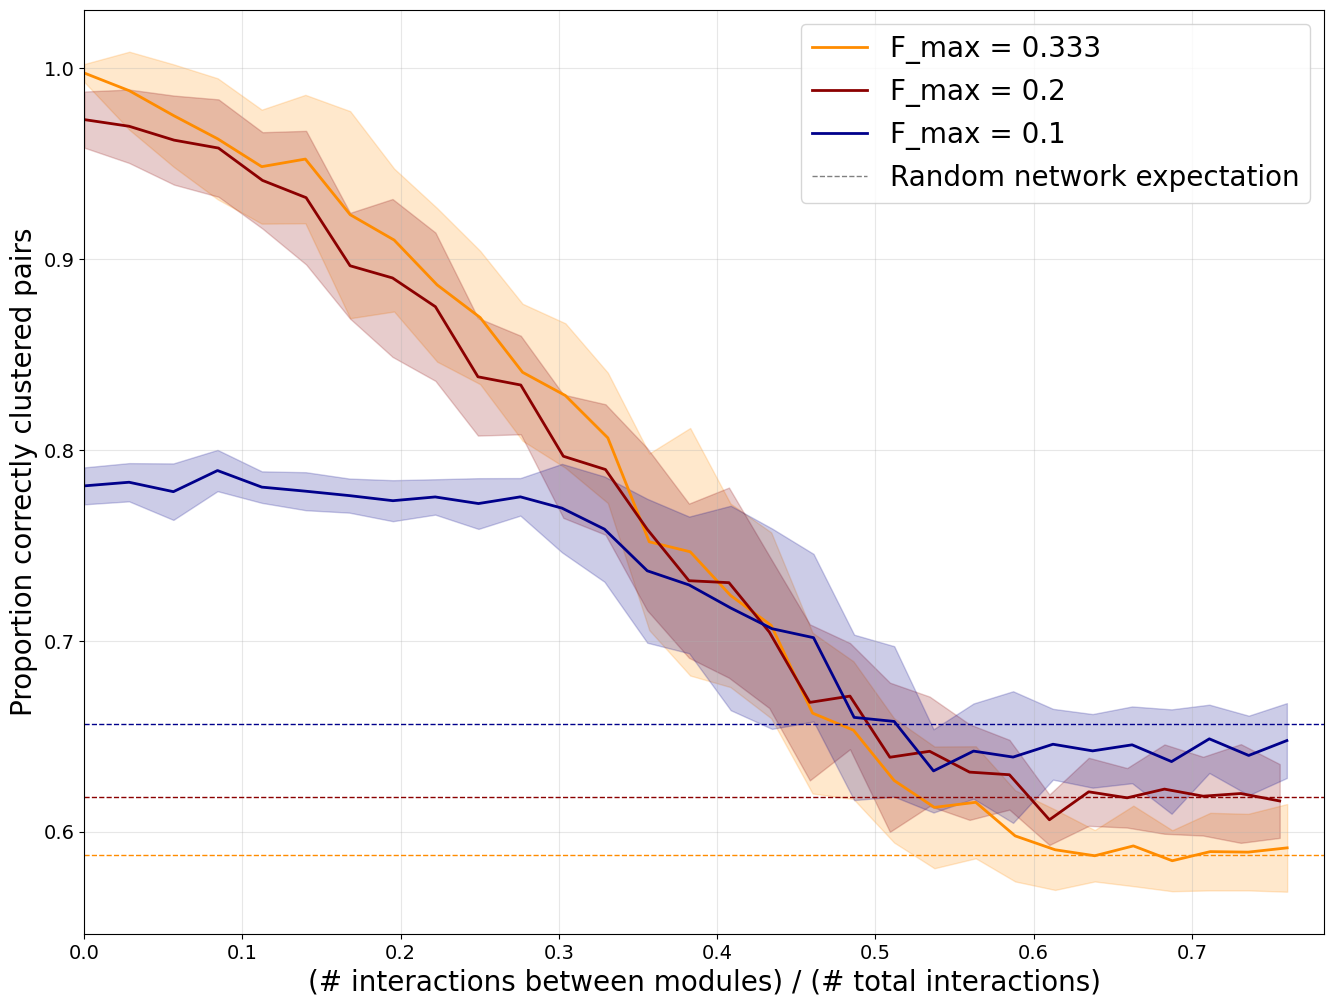

In [ ]:
# plot cluster correctness versus number of links between modules
plt.figure(figsize=(16, 12))
total_edges = edgeCounts[:,0,:,:] + edgeCounts[:,2,:,:]
edge_proportion = edgeCounts[:,2,:,:] / total_edges

# For each interactFactor value
for i, color in enumerate(['darkorange', 'darkred', 'darkblue']):
    x_mean = np.mean(edge_proportion[:, i, :], axis=-1)  
    y_mean = np.mean(correct_clust_res[:, 5, i, :], axis=-1)
    
    y_std = np.std(correct_clust_res[:, 5, i, :], axis=-1)
    
    # Plot the main line
    plt.plot(x_mean, y_mean, color=color, lw=2,
             label=f'F_max = {np.round(interactFactorL[i], 3)}')
    
    # Add shaded region for 1 std dev
    plt.fill_between(x_mean, 
                     y_mean - y_std, 
                     y_mean + y_std,
                     color=color, alpha=0.2)

plt.xlim(np.min(edge_proportion), np.max(edge_proportion))
plt.hlines(rand_prop_correct_3, xmin=0, xmax=maxEBetween, color='darkorange', lw=1, linestyle='--')
plt.hlines(rand_prop_correct_5, xmin=0, xmax=maxEBetween, color='darkred', lw=1, linestyle='--')
plt.hlines(rand_prop_correct_10, xmin=0, xmax=maxEBetween, color='darkblue', lw=1, linestyle='--')
plt.xlabel('(# interactions between modules) / (# total interactions)', fontsize = 20)
plt.ylabel('Proportion correctly clustered pairs', fontsize = 20)
plt.plot([], [], color='gray', lw=1, linestyle='--', label='Random network expectation')
plt.legend(fontsize = 20)
plt.grid(True, alpha=0.3)
plt.tick_params(labelsize=14)
plt.show()

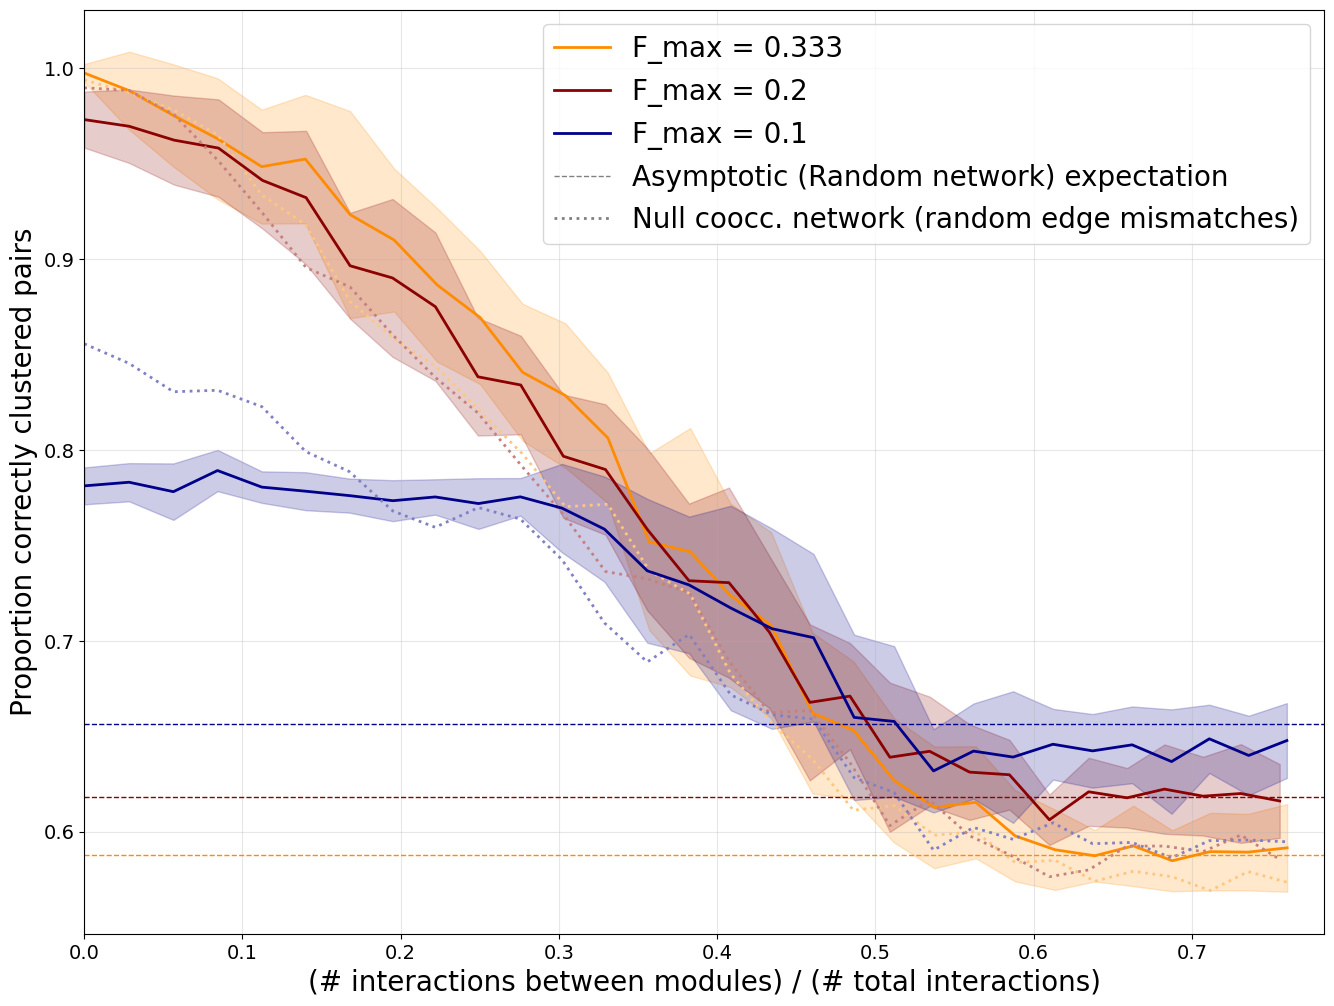

In [ ]:
# plot cluster correctness versus number of links between modules, with null-cooccurrence-network expectation
import matplotlib.colors as mcolors
def lighten(color, amount=0.5):
    c = np.array(mcolors.to_rgb(color))
    return tuple(c + (1 - c) * amount)

plt.figure(figsize=(16, 12))
total_edges = edgeCounts[:,0,:,:] + edgeCounts[:,2,:,:]
edge_proportion = edgeCounts[:,2,:,:] / total_edges

# For each interactFactor value
for i, color in enumerate(['darkorange', 'darkred', 'darkblue']):
    x_mean = np.mean(edge_proportion[:, i, :], axis=-1)  
    y_mean = np.mean(correct_clust_res[:, 5, i, :], axis=-1)
    
    y_std = np.std(correct_clust_res[:, 5, i, :], axis=-1)
    
    # Plot the main line
    plt.plot(x_mean, y_mean, color=color, lw=2,
             label=f'F_max = {np.round(interactFactorL[i], 3)}')
    
    # Add shaded region for 1 std dev
    plt.fill_between(x_mean, 
                     y_mean - y_std, 
                     y_mean + y_std,
                     color=color, alpha=0.2)

    # Plot the null-cooccurrence-network version (same x-axis, dotted line, lighter shade)
    y_null_mean = np.mean(correct_clust_res_null[:, i, :], axis=-1)
    plt.plot(x_mean, y_null_mean, color=lighten(color), lw=2, linestyle=':')

plt.xlim(np.min(edge_proportion), np.max(edge_proportion))
plt.hlines(rand_prop_correct_3, xmin=0, xmax=maxEBetween, color='darkorange', lw=1, linestyle='--')
plt.hlines(rand_prop_correct_5, xmin=0, xmax=maxEBetween, color='darkred', lw=1, linestyle='--')
plt.hlines(rand_prop_correct_10, xmin=0, xmax=maxEBetween, color='darkblue', lw=1, linestyle='--')
plt.xlabel('(# interactions between modules) / (# total interactions)', fontsize = 20)
plt.ylabel('Proportion correctly clustered pairs', fontsize = 20)
plt.plot([], [], color='gray', lw=1, linestyle='--', label='Asymptotic (Random network) expectation')
plt.plot([], [], color='gray', lw=2, linestyle=':', label='Null coocc. network (random edge mismatches)')
plt.legend(fontsize = 20)
plt.grid(True, alpha=0.3)
plt.tick_params(labelsize=14)
plt.show()

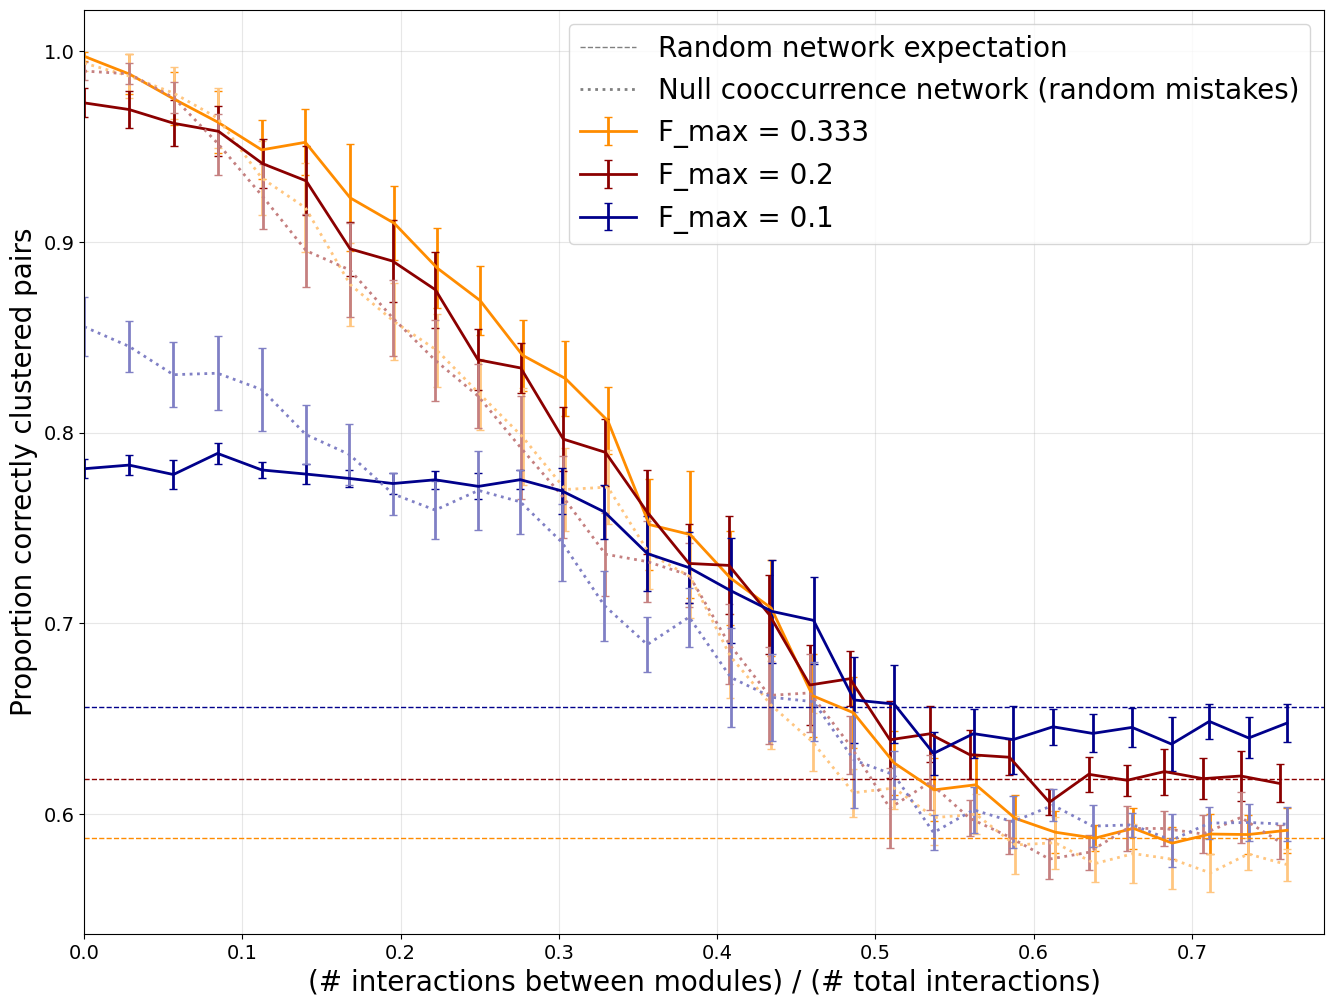

In [ ]:
# plot cluster correctness versus number of links between modules, with null-cooccurrence-network expectation (error bars = 2*SEM)
import matplotlib.colors as mcolors
def lighten(color, amount=0.5):
    c = np.array(mcolors.to_rgb(color))
    return tuple(c + (1 - c) * amount)

plt.figure(figsize=(16, 12))
total_edges = edgeCounts[:,0,:,:] + edgeCounts[:,2,:,:]
edge_proportion = edgeCounts[:,2,:,:] / total_edges
n_reps_here = correct_clust_res.shape[-1]

# For each interactFactor value
for i, color in enumerate(['darkorange', 'darkred', 'darkblue']):
    x_mean = np.mean(edge_proportion[:, i, :], axis=-1)  
    y_mean = np.mean(correct_clust_res[:, 5, i, :], axis=-1)
    y_sem = np.std(correct_clust_res[:, 5, i, :], axis=-1) / np.sqrt(n_reps_here)

    # Plot the main line with 2*SEM error bars
    plt.errorbar(x_mean, y_mean, yerr=2*y_sem, color=color, lw=2, capsize=3,
             label=f'F_max = {np.round(interactFactorL[i], 3)}')

    # Plot the null-cooccurrence-network version (same x-axis, dotted line, lighter shade) with 2*SEM error bars
    y_null_mean = np.mean(correct_clust_res_null[:, i, :], axis=-1)
    y_null_sem = np.std(correct_clust_res_null[:, i, :], axis=-1) / np.sqrt(n_reps_here)
    plt.errorbar(x_mean, y_null_mean, yerr=2*y_null_sem, color=lighten(color), lw=2, linestyle=':', capsize=3)

plt.xlim(np.min(edge_proportion), np.max(edge_proportion))
plt.hlines(rand_prop_correct_3, xmin=0, xmax=maxEBetween, color='darkorange', lw=1, linestyle='--')
plt.hlines(rand_prop_correct_5, xmin=0, xmax=maxEBetween, color='darkred', lw=1, linestyle='--')
plt.hlines(rand_prop_correct_10, xmin=0, xmax=maxEBetween, color='darkblue', lw=1, linestyle='--')
plt.xlabel('(# interactions between modules) / (# total interactions)', fontsize = 20)
plt.ylabel('Proportion correctly clustered pairs', fontsize = 20)
plt.plot([], [], color='gray', lw=1, linestyle='--', label='Random network expectation')
plt.plot([], [], color='gray', lw=2, linestyle=':', label='Null cooccurrence network (random mistakes)')
plt.legend(fontsize = 20)
plt.grid(True, alpha=0.3)
plt.tick_params(labelsize=14)
plt.show()

In [ ]:
# scratch


modSize = nSpec // nModules
modules = [range(i * modSize, (i+1) * modSize) for i in range(nModules)]
modules

[range(0, 20), range(20, 40), range(40, 60), range(60, 80), range(80, 100)]

## Compositional analysis (relative abundances)

1721
0


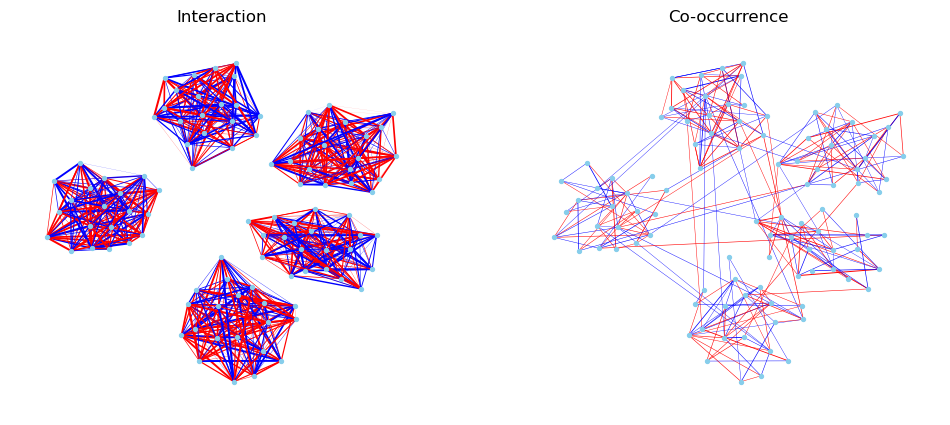

1526
195


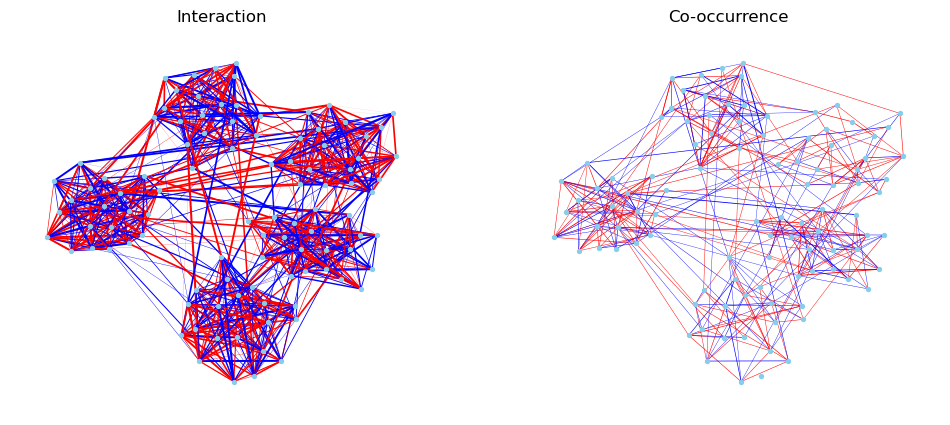

1333
388


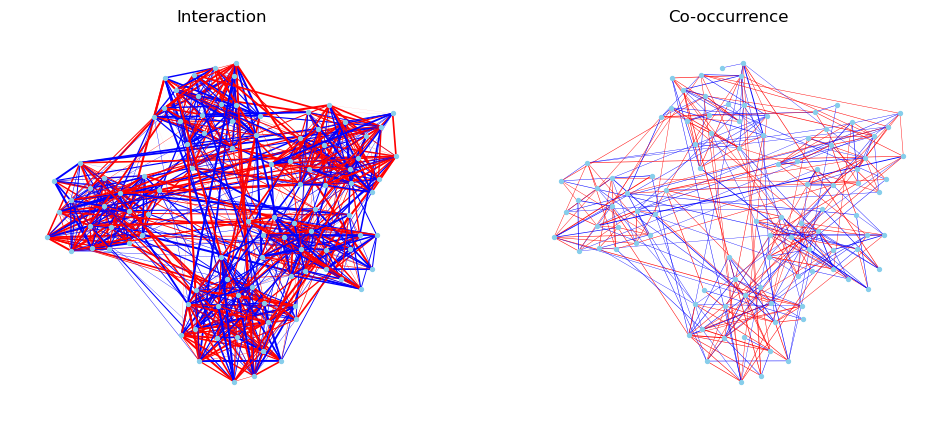

1150
571


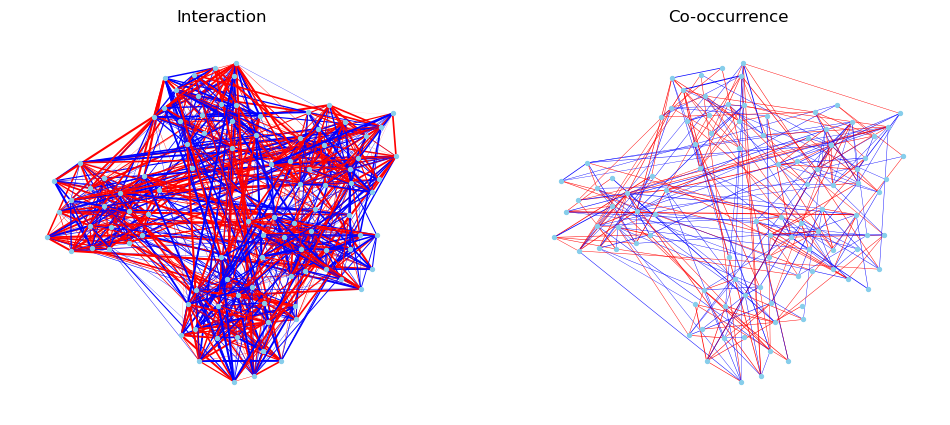

In [ ]:
modSize = nSpec // nModules
myModules = [range(i * modSize, (i+1) * modSize) for i in range(nModules)]

step = 50
maxEBetween = 1500

####### to get null expectation for random network
interactFactor = 1/10
randMx = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactFactor * alpha, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)

network_comp_rand, G_comp_rand_coocc = run_cooccurrence.get_coocc_network(interactionMx = randMx, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, pval_alpha = 0.01, compositional = True)
rand_comp_clust_coocc_gr = nx.community.greedy_modularity_communities(G_comp_rand_coocc)

G_rand_inter = nx.from_numpy_array(randMx != 0)
rand_comp_clust_inter_gr = nx.community.greedy_modularity_communities(G_rand_inter)

rand_comp_shared_pairs_10, rand_comp_both_non_pairs_10, rand_comp_c1_not_c2_10, rand_comp_c2_not_c1_10, rand_comp_prop_correct_10 = \
                metrics_and_plotting.test_cluster_similarity(rand_comp_clust_coocc_gr, rand_comp_clust_inter_gr)

interactFactor = 1/5
randMx = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactFactor * alpha, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)

network_comp_rand, G_comp_rand_coocc = run_cooccurrence.get_coocc_network(interactionMx = randMx, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, pval_alpha = 0.01, compositional = True)
rand_comp_clust_coocc_gr = nx.community.greedy_modularity_communities(G_comp_rand_coocc)

G_rand_inter = nx.from_numpy_array(randMx != 0)
rand_comp_clust_inter_gr = nx.community.greedy_modularity_communities(G_rand_inter)

rand_comp_shared_pairs_3, rand_comp_both_non_pairs_5, rand_comp_c1_not_c2_5, rand_comp_c2_not_c1_5, rand_comp_prop_correct_5 = \
                metrics_and_plotting.test_cluster_similarity(rand_comp_clust_coocc_gr, rand_comp_clust_inter_gr)

interactFactor = 1/3
randMx = metaCommunityMx.getRandomMatrix(maxInteractionStrength = interactFactor * alpha, pPositive = pPositive, pInteract = pInteract, nSpecies = nSpec, pBidirectional = 0)

network_comp_rand, G_comp_rand_coocc = run_cooccurrence.get_coocc_network(interactionMx = randMx, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, pval_alpha = 0.01, compositional = True)
rand_comp_clust_coocc_gr = nx.community.greedy_modularity_communities(G_comp_rand_coocc)

G_rand_inter = nx.from_numpy_array(randMx != 0)
rand_comp_clust_inter_gr = nx.community.greedy_modularity_communities(G_rand_inter)

rand_comp_shared_pairs_3, rand_comp_both_non_pairs_3, rand_comp_c1_not_c2_3, rand_comp_c2_not_c1_3, rand_comp_prop_correct_3 = \
                metrics_and_plotting.test_cluster_similarity(rand_comp_clust_coocc_gr, rand_comp_clust_inter_gr)

####### get positions for the graphs
modMx = metaCommunityMx.generateModularMatrix(maxInteractionStrength = (1/10) * alpha, pPositive = pPositive, nSpecies = nSpec, pWithinMod = pWithinMod, pBetweenMod = 0, nModules = nModules)
modMxPositional = metrics_and_plotting.rewire_modular(matrix = modMx, modules = myModules, nEdges = 200, interactStren = (1/10) * alpha)
G_inter = nx.from_numpy_array(modMxPositional != 0)
pos = nx.spring_layout(G_inter, seed=42)
#######

n_reps = 5
interactFactorL = [1/3, 1/5, 1/10]
correct_clust_res_comp = np.zeros(shape = (maxEBetween//step, 6, len(interactFactorL), n_reps))
edgeCounts_comp = np.zeros(shape = (maxEBetween//step, 4, len(interactFactorL), n_reps))
correct_clust_res_comp_null = np.zeros(shape = (maxEBetween//step, len(interactFactorL), n_reps))
for iiii in range(n_reps):
    for iii in range(len(interactFactorL)):
        interactFactor = interactFactorL[iii]
        interactStren = alpha * interactFactor
        modMx = metaCommunityMx.generateModularMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, nSpecies = nSpec, pWithinMod = pWithinMod, pBetweenMod = 0, nModules = nModules)

        i = 0
        for nBetween in range(0, maxEBetween, step): # slowly increase the number of links between modules
            # run simulation to get cooccurrence and make clusters
            if nBetween in [0, 200, 400, 600] and interactFactor == 1/5 and iiii == 0:
                plotNet = True
                edgeCountWithin, possibleWithin, edgeCountBetween, possibleBetween = metrics_and_plotting.prop_within_btwn_mod(nSpec, nModules, modMx)
                print(edgeCountWithin)
                print(edgeCountBetween)
            else: 
                plotNet = False
            network_comp_mod, G_comp_mod_coocc, pearson_comp_mod = run_cooccurrence.get_coocc_network(interactionMx = modMx, cutoff = None, alpha = alpha, spsamplesize = samplesize, \
                                                                          numtrials = numtrials, b = b, plotNetworks = plotNet, pval_alpha = 0.01, pos = pos, return_pearson = True, compositional = True)
            if plotNet:
                with open(f'figure_data/mcc_network_comp_nBetween{nBetween}.pkl', 'wb') as f:
                    pickle.dump({
                        'interactionMx': modMx,
                        'network_comp_coocc': network_comp_mod,
                        'pearson_comp_corr': pearson_comp_mod,
                        'pos': pos,
                        'nBetween': nBetween,
                    }, f)
            mod_comp_clust_coocc_gr = nx.community.greedy_modularity_communities(G_comp_mod_coocc)

            # make interaction clusters
            G_mod_inter = nx.from_numpy_array(modMx != 0)
            mod_comp_clust_inter_gr = nx.community.greedy_modularity_communities(G_mod_inter)

            # compare interaction clusters and cooccurrence clusters
            mod_comp_shared_pairs, mod_comp_both_non_pairs, mod_comp_c1_not_c2, mod_comp_c2_not_c1, mod_comp_prop_correct = \
                        metrics_and_plotting.test_cluster_similarity(mod_comp_clust_coocc_gr, mod_comp_clust_inter_gr)
            correct_clust_res_comp[i,:,iii,iiii] = np.array([nBetween, mod_comp_shared_pairs, mod_comp_both_non_pairs, mod_comp_c1_not_c2, mod_comp_c2_not_c1, mod_comp_prop_correct])

            # null cooccurrence network: same number of false pos/neg as the real cooc network, but in random positions
            null_comp_cooc_net, _ = metrics_and_plotting.make_random_mistakes(modMx, network_comp_mod)
            G_comp_null_coocc = nx.from_numpy_array(null_comp_cooc_net)
            null_comp_clust_coocc_gr = nx.community.greedy_modularity_communities(G_comp_null_coocc)
            _, _, _, _, mod_comp_prop_correct_null = \
                        metrics_and_plotting.test_cluster_similarity(null_comp_clust_coocc_gr, mod_comp_clust_inter_gr)
            correct_clust_res_comp_null[i,iii,iiii] = mod_comp_prop_correct_null

            edgeCountWithin, possibleWithin, edgeCountBetween, possibleBetween = metrics_and_plotting.prop_within_btwn_mod(nSpec, nModules, modMx)
            edgeCounts_comp[i, :, iii, iiii] = np.array([edgeCountWithin, possibleWithin, edgeCountBetween, possibleBetween])

            modMx = metrics_and_plotting.rewire_modular(matrix = modMx, modules = myModules, nEdges = step, interactStren = interactStren)
            i += 1

1708
0
0.0


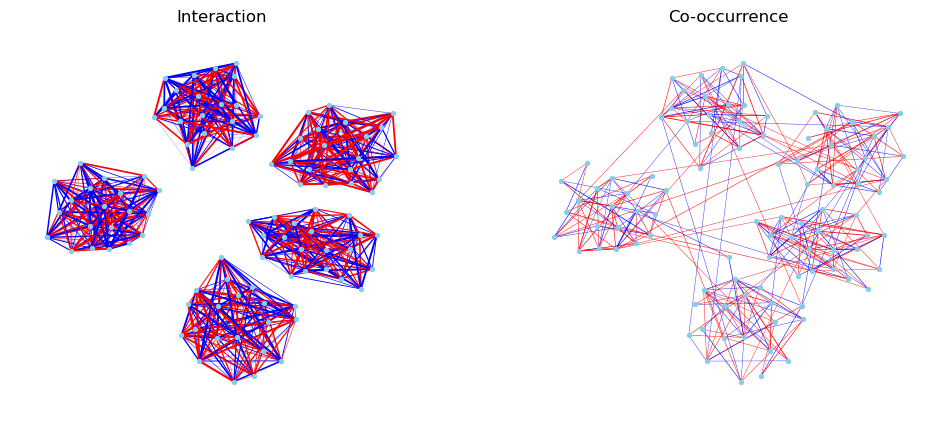

1514
194
0.11358313817330211


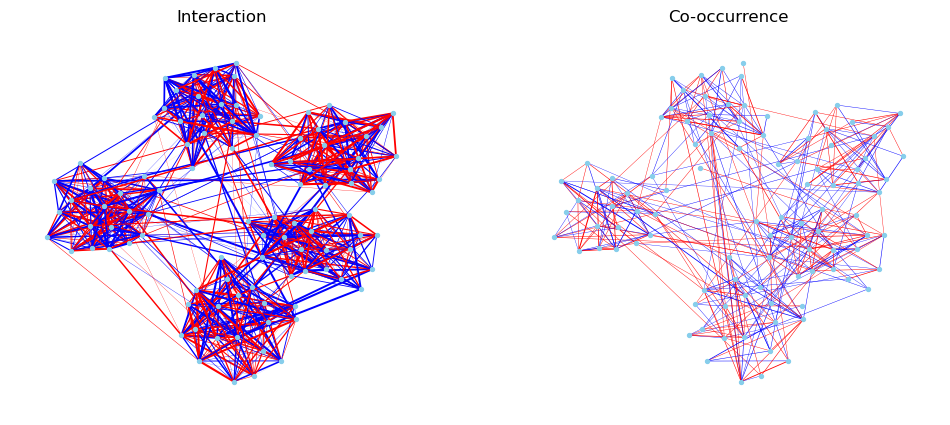

1323
385
0.22540983606557377


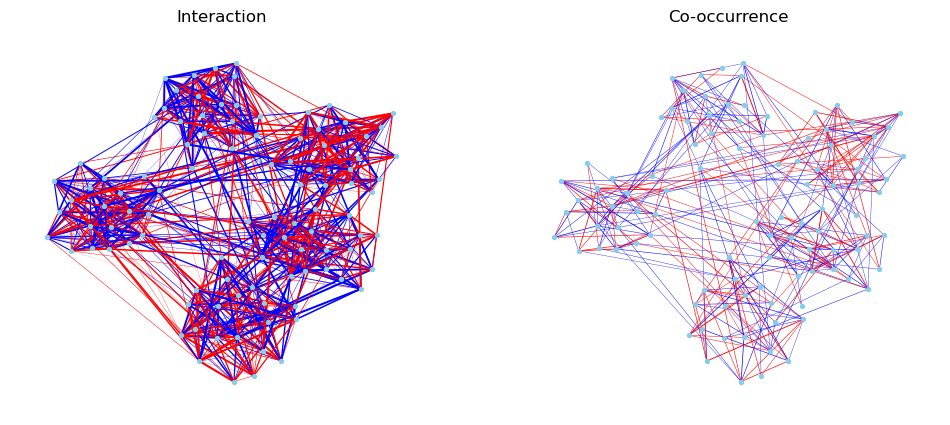

1136
572
0.33489461358313816


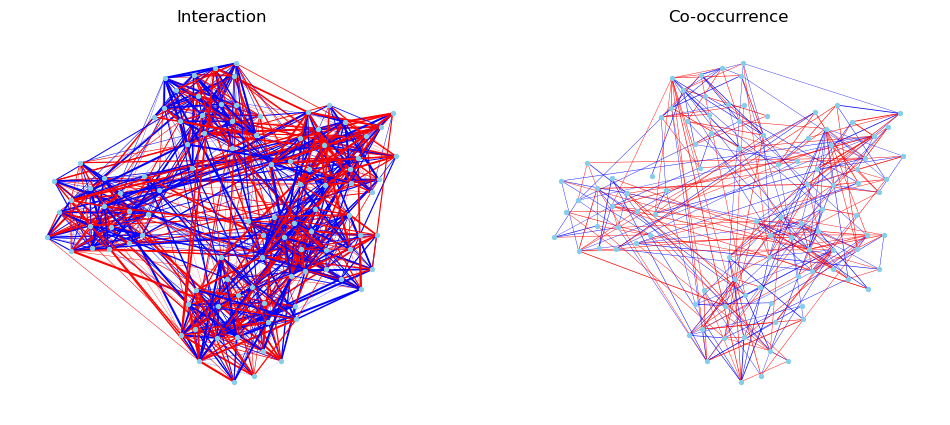

951
757
0.44320843091334894


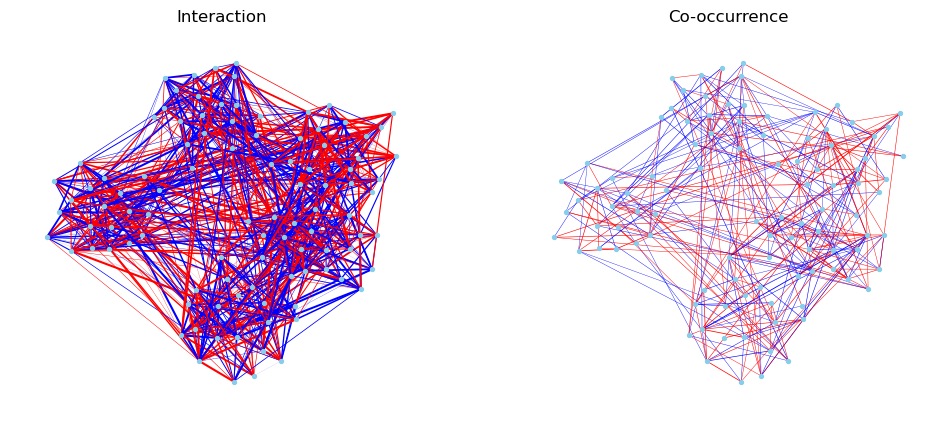

761
947
0.5544496487119438


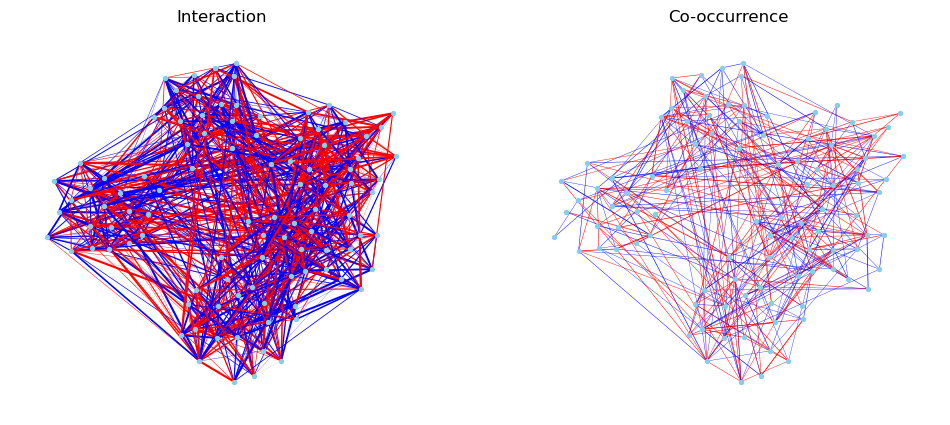

593
1115
0.6528103044496487


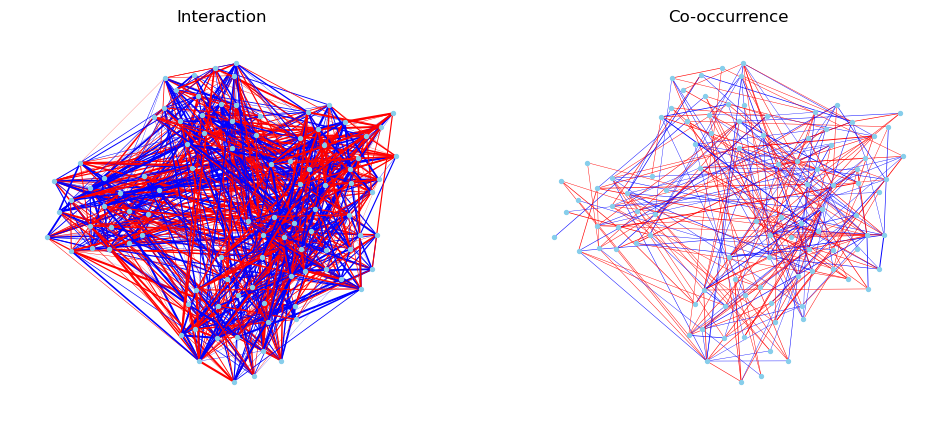

In [ ]:
interactFactor = 1/5
interactStren = alpha * interactFactor
modMx = metaCommunityMx.generateModularMatrix(maxInteractionStrength = interactStren, pPositive = pPositive, nSpecies = nSpec, pWithinMod = pWithinMod, pBetweenMod = 0, nModules = nModules)

step = 200
maxEBetween = 1400
i = 0
for nBetween in range(0, maxEBetween, step): # slowly increase the number of links between modules
    # run simulation to get cooccurrence and make clusters
    plotNet = True
    edgeCountWithin, possibleWithin, edgeCountBetween, possibleBetween = metrics_and_plotting.prop_within_btwn_mod(nSpec, nModules, modMx)
    print(edgeCountWithin)
    print(edgeCountBetween)
    print(edgeCountBetween / (edgeCountWithin+edgeCountBetween))
    network_comp_mod, G_comp_mod_coocc, pearson_comp_mod = run_cooccurrence.get_coocc_network(interactionMx = modMx, cutoff = None, alpha = alpha, spsamplesize = samplesize, numtrials = numtrials, b = b, plotNetworks = plotNet, pval_alpha = 0.01, pos = pos, return_pearson = True, compositional = True)
    with open(f'figure_data/mcc_network_comp_vis_nBetween{nBetween}.pkl', 'wb') as f:
        pickle.dump({
            'interactionMx': modMx,
            'network_comp_coocc': network_comp_mod,
            'pearson_comp_corr': pearson_comp_mod,
            'pos': pos,
            'nBetween': nBetween,
        }, f)
    modMx = metrics_and_plotting.rewire_modular(matrix = modMx, modules = myModules, nEdges = step, interactStren = interactStren)

In [ ]:
with open('figure_data/mcc_cluster_correctness_comp.pkl', 'wb') as f:
    pickle.dump({
        'edgeCounts_comp': edgeCounts_comp,
        'correct_clust_res_comp': correct_clust_res_comp,
        'correct_clust_res_comp_null': correct_clust_res_comp_null,
        'interactFactorL': interactFactorL,
        'n_reps': n_reps,
        'maxEBetween': maxEBetween,
        'rand_comp_prop_correct_3': rand_comp_prop_correct_3,
        'rand_comp_prop_correct_5': rand_comp_prop_correct_5,
        'rand_comp_prop_correct_10': rand_comp_prop_correct_10,
    }, f)

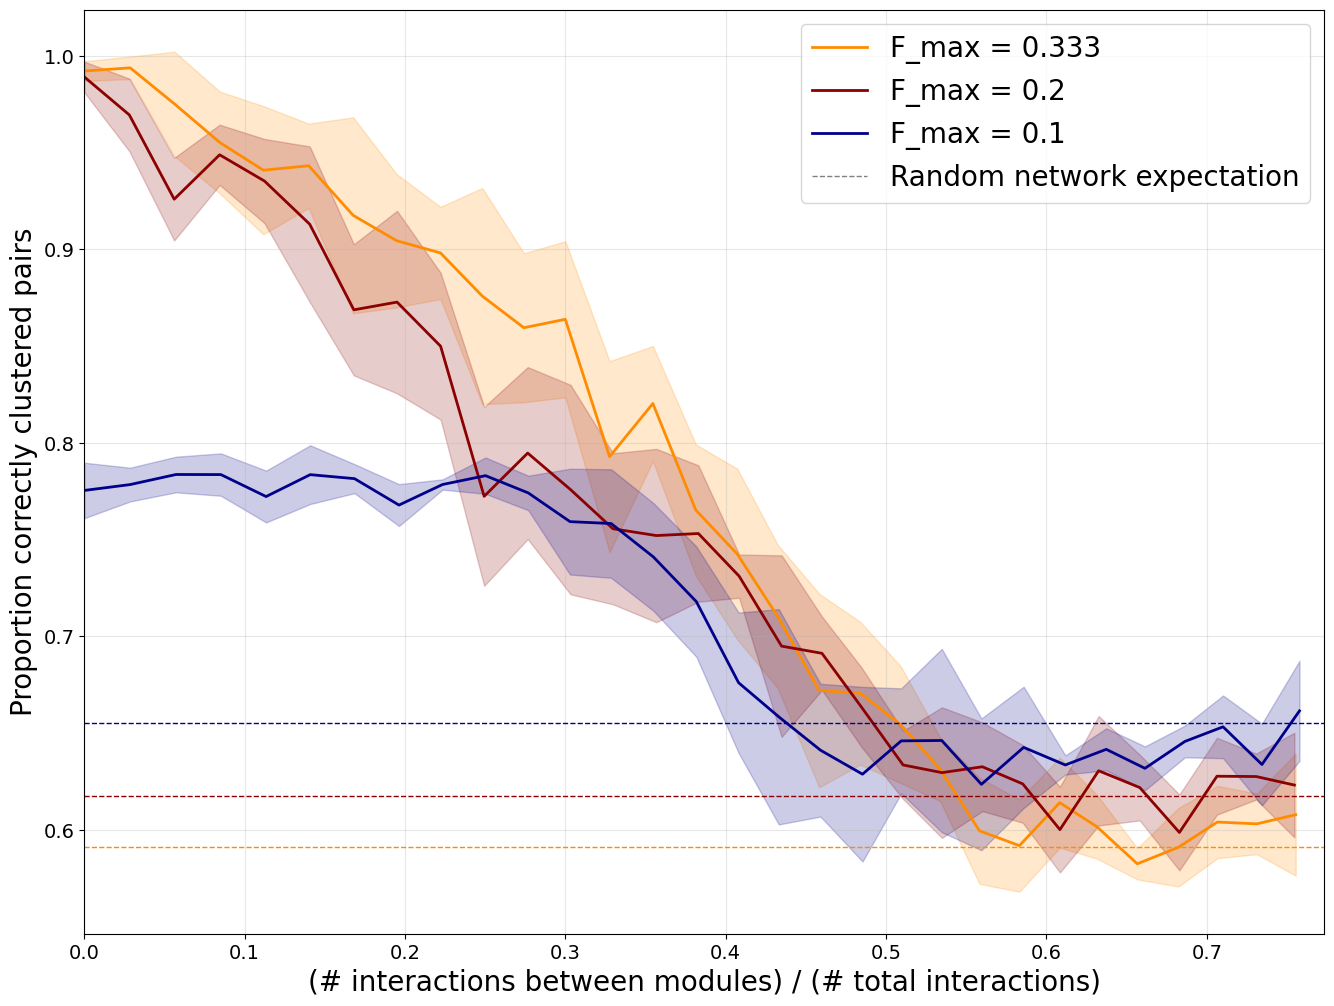

In [ ]:
# plot cluster correctness versus number of links between modules
plt.figure(figsize=(16, 12))
total_edges_comp = edgeCounts_comp[:,0,:,:] + edgeCounts_comp[:,2,:,:]
edge_proportion_comp = edgeCounts_comp[:,2,:,:] / total_edges_comp

# For each interactFactor value
for i, color in enumerate(['darkorange', 'darkred', 'darkblue']):
    x_mean = np.mean(edge_proportion_comp[:, i, :], axis=-1)  
    y_mean = np.mean(correct_clust_res_comp[:, 5, i, :], axis=-1)
    
    y_std = np.std(correct_clust_res_comp[:, 5, i, :], axis=-1)
    
    # Plot the main line
    plt.plot(x_mean, y_mean, color=color, lw=2,
             label=f'F_max = {np.round(interactFactorL[i], 3)}')
    
    # Add shaded region for 1 std dev
    plt.fill_between(x_mean, 
                     y_mean - y_std, 
                     y_mean + y_std,
                     color=color, alpha=0.2)

plt.xlim(np.min(edge_proportion_comp), np.max(edge_proportion_comp))
plt.hlines(rand_comp_prop_correct_3, xmin=0, xmax=maxEBetween, color='darkorange', lw=1, linestyle='--')
plt.hlines(rand_comp_prop_correct_5, xmin=0, xmax=maxEBetween, color='darkred', lw=1, linestyle='--')
plt.hlines(rand_comp_prop_correct_10, xmin=0, xmax=maxEBetween, color='darkblue', lw=1, linestyle='--')
plt.xlabel('(# interactions between modules) / (# total interactions)', fontsize = 20)
plt.ylabel('Proportion correctly clustered pairs', fontsize = 20)
plt.plot([], [], color='gray', lw=1, linestyle='--', label='Random network expectation')
plt.legend(fontsize = 20)
plt.grid(True, alpha=0.3)
plt.tick_params(labelsize=14)
plt.show()

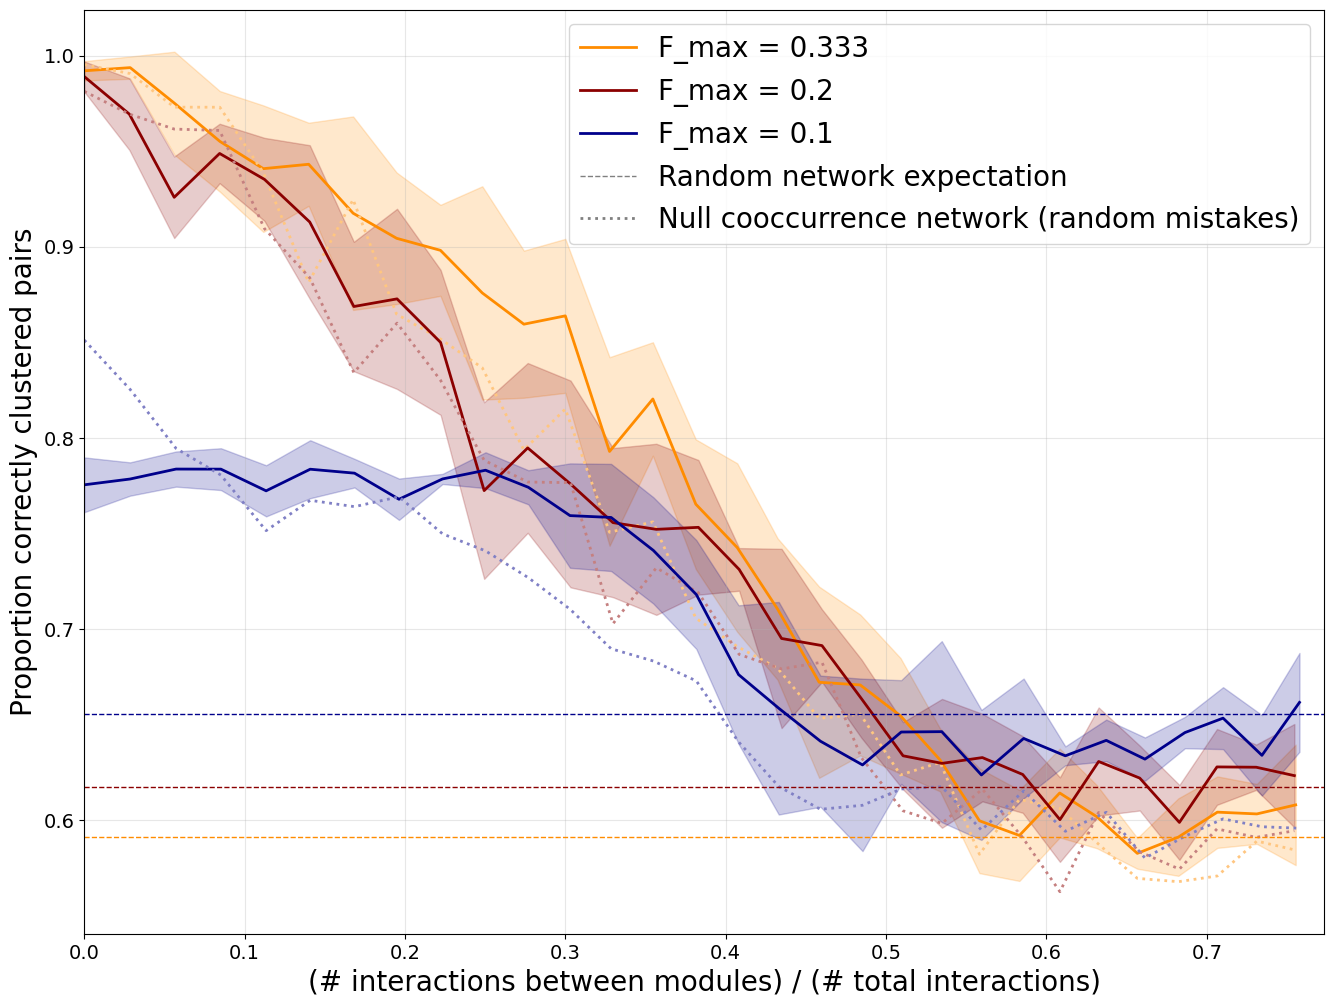

In [ ]:
# plot cluster correctness versus number of links between modules, with null-cooccurrence-network expectation
import matplotlib.colors as mcolors
def lighten(color, amount=0.5):
    c = np.array(mcolors.to_rgb(color))
    return tuple(c + (1 - c) * amount)

plt.figure(figsize=(16, 12))
total_edges_comp = edgeCounts_comp[:,0,:,:] + edgeCounts_comp[:,2,:,:]
edge_proportion_comp = edgeCounts_comp[:,2,:,:] / total_edges_comp

# For each interactFactor value
for i, color in enumerate(['darkorange', 'darkred', 'darkblue']):
    x_mean = np.mean(edge_proportion_comp[:, i, :], axis=-1)  
    y_mean = np.mean(correct_clust_res_comp[:, 5, i, :], axis=-1)
    
    y_std = np.std(correct_clust_res_comp[:, 5, i, :], axis=-1)
    
    # Plot the main line
    plt.plot(x_mean, y_mean, color=color, lw=2,
             label=f'F_max = {np.round(interactFactorL[i], 3)}')
    
    # Add shaded region for 1 std dev
    plt.fill_between(x_mean, 
                     y_mean - y_std, 
                     y_mean + y_std,
                     color=color, alpha=0.2)

    # Plot the null-cooccurrence-network version (same x-axis, dotted line, lighter shade)
    y_null_mean = np.mean(correct_clust_res_comp_null[:, i, :], axis=-1)
    plt.plot(x_mean, y_null_mean, color=lighten(color), lw=2, linestyle=':')

plt.xlim(np.min(edge_proportion_comp), np.max(edge_proportion_comp))
plt.hlines(rand_comp_prop_correct_3, xmin=0, xmax=maxEBetween, color='darkorange', lw=1, linestyle='--')
plt.hlines(rand_comp_prop_correct_5, xmin=0, xmax=maxEBetween, color='darkred', lw=1, linestyle='--')
plt.hlines(rand_comp_prop_correct_10, xmin=0, xmax=maxEBetween, color='darkblue', lw=1, linestyle='--')
plt.xlabel('(# interactions between modules) / (# total interactions)', fontsize = 20)
plt.ylabel('Proportion correctly clustered pairs', fontsize = 20)
plt.plot([], [], color='gray', lw=1, linestyle='--', label='Random network expectation')
plt.plot([], [], color='gray', lw=2, linestyle=':', label='Null cooccurrence network (random mistakes)')
plt.legend(fontsize = 20)
plt.grid(True, alpha=0.3)
plt.tick_params(labelsize=14)
plt.show()